In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# MNIST tensor transform
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)




100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.63MB/s]


Class 1 (positive) means digit 0

Class 0 (negative) means digit 1 to 9

In [4]:
mnist_train.data.shape, mnist_test.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [14]:
#mnist_train[1][0]

In [23]:
len(mnist_train.targets)

60000

In [24]:
len(mnist_test.targets)

10000

In [19]:
mnist_train.targets == 0

tensor([False,  True, False,  ..., False, False, False])

In [20]:
(mnist_train.targets == 0).float()

tensor([0., 1., 0.,  ..., 0., 0., 0.])

In [35]:
# Binary targets: 1 for '0', 0 for others.........
#Labels are converted to binary: 1 if the digit is 0, else 0 (for other digits 1 to 9).
mnist_train.targets = (mnist_train.targets == 0).float()
mnist_test.targets = (mnist_test.targets == 0).float()

In [36]:
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=256)

defines a simple feedforward neural network model using PyTorch's nn.Sequential container. Here's a detailed breakdown of what each layer does:

**nn.Flatten():** This flattens the input image tensor from shape
(
b
a
t
c
h
_
s
i
z
e
,
1
,
28
,
28
)
(batch_size,1,28,28) to
(
b
a
t
c
h
_
s
i
z
e
,
784
)
(batch_size,784), converting the 2D 28x28 pixel image into a 1D vector suitable for the linear layers.

**nn.Linear(28*28, 128):** A fully connected (dense) layer that takes the 784-dimensional input vector and maps it to 128 features (nodes). This is the first hidden layer.

**nn.ReLU():** Applies the ReLU (Rectified Linear Unit) activation function element-wise to introduce non-linearity, enabling the network to learn complex patterns.

**nn.Linear(128, 1):** The output layer, a fully connected layer that maps 128 features down to a single output value (logit). Since this is for binary classification, a single output neuron suffices.

**.to(device):** Moves the model's parameters to the specified device, either CPU or GPU for accelerated computing.

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()


In [39]:
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        x = images.to(device)
        y = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(x).squeeze(-1)     #squeeze(-1) means remove the last dimension if its size is 1.
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    print('Epoch', epoch+1, 'Train Loss:', avg_loss)


Epoch 1 Train Loss: 0.0457468188383927
Epoch 2 Train Loss: 0.021405803733908883
Epoch 3 Train Loss: 0.01479166383103778
Epoch 4 Train Loss: 0.009871461923214761
Epoch 5 Train Loss: 0.0074546923720433065


In [56]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        x = images.to(device)
        y = labels.to(device)
        logits = model(x).squeeze(-1)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)
test_acc = correct / total
print('Test Accuracy:', test_acc)


Test Accuracy: 0.9972


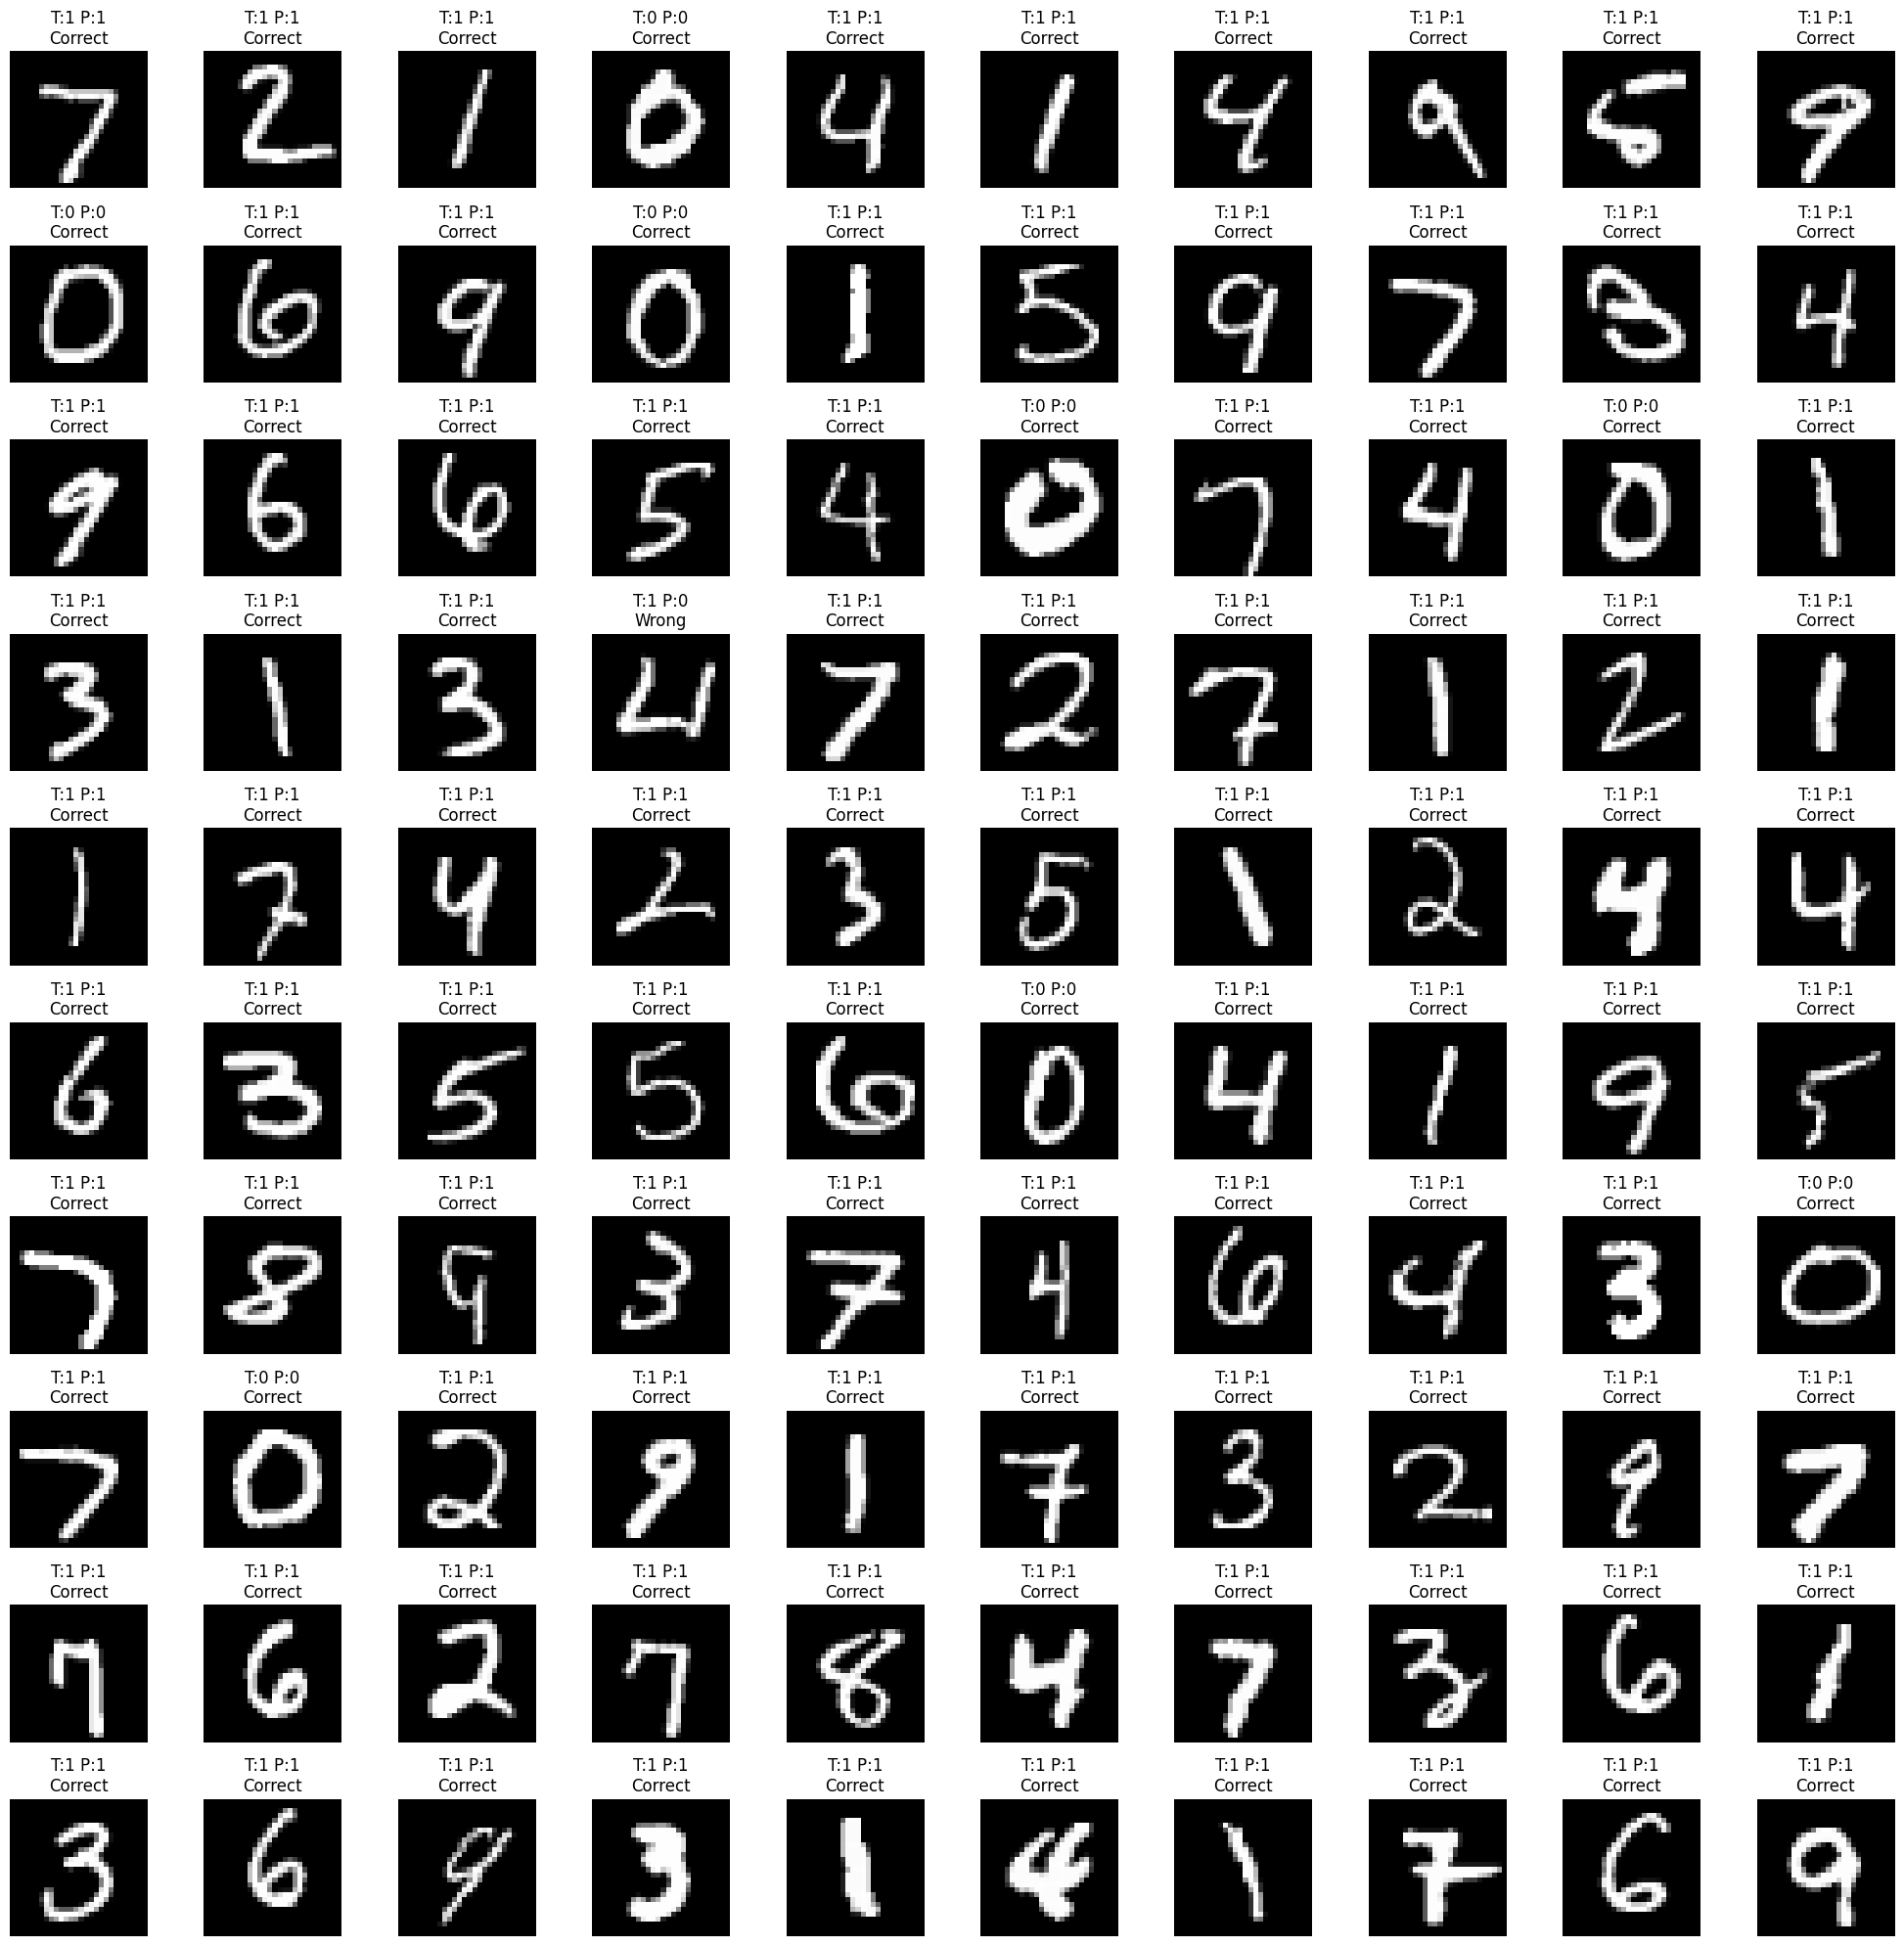

Test Accuracy: 0.99


In [58]:
import matplotlib.pyplot as plt

model.eval()
correct, total = 0, 0
n_show = 100  # number of images to show
n_cols = 10   # number of columns in grid
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
axes = axes.flatten()

with torch.no_grad():
    for images, labels in test_loader:
        x = images.to(device)
        y = labels.to(device)
        logits = model(x).squeeze(-1)
        preds = (torch.sigmoid(logits) > 0.5).float()

        for i in range(min(n_show, len(images))):
            img = images[i].cpu().squeeze().numpy()
            pred_label = int(preds[i].item())
            true_label = int(y[i].item())
            correct_flag = (pred_label == true_label)

            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"T:{true_label} P:{pred_label}\n{'Correct' if correct_flag else 'Wrong'}")
            axes[i].axis('off')

            if correct_flag:
                correct += 1
            total += 1

        break  # only show first batch

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

test_acc = correct / total
print('Test Accuracy:', test_acc)
